In [1]:
import casadi as ca
import numpy as np
import math
import control as ct
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec


Our LQR gain matrix uses the following:

Max errors for each variable
- $x$: 1e-6
- $y$: 1e-6
- $z$: +-20m max so (1/20**2) = 0.0025
- $\phi,(\text{roll})$: +-$\pi$ so (1/$\pi^{2}$)
- $\theta,(\text{pitch})$: +-$\frac{\pi}{2}$ so 1/$(\frac{\pi}{2})^{2}$
- $\psi,(\text{yaw})$: +-$\pi$ so (1/$\pi^{2}$) - might actually want to increase more so we don't penalise yaw as much
- $\dot{x}$: 1e-6
- $\dot{y}$: 1e-6
- $\dot{z}$: +-5m/s max so (1/5**2) = 0.04
- $\dot{\phi}$: +-$\frac{\pi}{2}$rad/s max so 1/$(\frac{\pi}{2})^{2}$
- $\dot{\theta}$: +-$\frac{\pi}{2}$rad/s max so 1/$(\frac{\pi}{2})^{2}$
- $\dot{\psi}$: +-$\frac{\pi}{4}$rad/s max so 1/$(\frac{\pi}{4})^{2}$

In [11]:
from common.dynamics import mincopter_dynamics

mass = 2.43
g = 9.81
dt = 0.01
dynamics, lin_dynamics = mincopter_dynamics(mass=mass, dt=dt)

parms = {"Q": np.eye(12), "R": np.eye(4), "N": 10, "Qf": np.eye(12), "dynamic": True}

## LQR and riccati equation
#Q = np.diag([1e-9, 1e-9, 1/(20**2), 1, 1, 1, 1e-9, 1e-9, 0.05, 0.1,0.1,0.1])
#Q = np.diag([1e-3, 1e-3, 1/(20**2), 1, 1, 1, 1e-9, 1e-9, 0.05, 0.1,0.1,0.1])
'''
Q = np.diag([1e-6, 1e-6,1/(20**2),
             1/(math.pi**2), 1/((math.pi/2)**2), 1/(math.pi**2),
             1e-6, 1e-6, (1/5**2),
             1/((math.pi/2)**2), 1/((math.pi/2)**2), 1/((math.pi/4)**2)])
'''
Q = np.diag([1/(1**2), 1/(1**2),1/(20**2),
             1/(math.pi**2), 1/((math.pi/2)**2), 1/((math.pi/2)**2),
             1/(0.5**2), 1/(0.5**2), (1/5**2),
             1/((math.pi/2)**2), 1/((math.pi/2)**2), 1/((math.pi/4)**2)])

R = np.diag([0.05, 5, 5, 5])

## NOTE Do we use the continuous or discrete form here for the LQR controller??

lqr_k, _, _ = ct.lqr(lin_dynamics.A,lin_dynamics.B,Q,R)
for i in range(0,4):
    for j in range(0,12):
        if abs(lqr_k[i,j]) < 1e-6:
            lqr_k[i,j]=0
        print(f"{lqr_k[i,j]:+6.4f} ", end='')
    print()

+4.2649 +0.0000 -97200.3292 +0.0000 -0.0007 +0.0000 -0.0002 +0.0000 -486.0000 +0.0000 +0.0000 +0.0000 
+0.0000 +1344873.4980 +0.0000 +539.8868 +0.0000 +0.0000 +0.0000 +6523.9552 +0.0000 +2.1333 +0.0000 +0.0000 
-2468315.7727 +0.0000 +0.0017 +0.0000 +1003.5696 +0.0000 -12232.4181 +0.0000 +0.0000 +0.0000 +4.0000 +0.0000 
+0.0000 -0.0003 +0.0000 +0.0000 +0.0000 +698.5655 +0.0000 +0.0000 +0.0000 +0.0000 +0.0000 +3.4000 


In [12]:
## Simulation Setup
#iterations = 10*100
iterations=1000
x_bag = np.zeros((12, iterations))
time = np.linspace(0,1,100)

temp_x = [0, 0, 10, 0.1, 0, -0.1, 0, 0, 0, 0, 0, 0]
temp_u = [0, 0, 0, 0]

## Control variables

# Destination (NED frame, metres)
target_x = 50
target_y = 50
target_z = -20 ## Indicates 20 metres above "ground" or "0 alt"
target_yaw = 0 ## No yawing required for our waypoint controller

## Reset all PID controllers
'''
for c in controller_array:
    c.reset()
    c.reset_logging()
'''

## Intermediate variables that we want to plot
ctx = {
    'c_roll_out': [],
    'c_pitch_out': [],
    'c_yaw_out': [],
    'c_throttle_out': [],
    'mot_0': [],
    'mot_1': [],
    'mot_2': [],
    'mot_3': [],
    'u_force': [],
    'u_rtorque': [],
    'u_ptorque': [],
    'u_ytorque': []
}

desired_roll = 0
desired_pitch = 0

## 1 second simulation
for j in range(0,iterations):

    ## Add the reference **to a copy**
    new_tx = temp_x.copy()
    new_tx[2] -= target_z
    #new_tx[3] -= 1 ## Target roll

    ## Apply LQR gain to state
    lqr_out = -lqr_k@new_tx
    
    '''
    temp_u = [-10-rthrottle_output,
              rroll_output,
              rpitch_output,
              ryaw_output]
    '''
    temp_u = [mass*g+lqr_out[0], lqr_out[1], lqr_out[2], lqr_out[3]]
    
    ## Constrain force between [0,20] : 0 is no throttle and 20 is full throttle
    if temp_u[0]<0:
        temp_u[0]=0
    elif temp_u[0]>50:
        temp_u[0]=50
    
    # Store intermediate variables
    ctx['u_force'].append(temp_u[0])
    ctx['u_rtorque'].append(temp_u[1])
    ctx['u_ptorque'].append(temp_u[2])
    ctx['u_ytorque'].append(temp_u[3])

    # Feed dynamics
    temp_x = dynamics(temp_x, temp_u).full()

    # Wrap roll/pitch/yaw
    ## TODO

    # Record output for plotting
    x_bag[:, j] = temp_x.reshape((12,))
    temp_x = temp_x.reshape((12,))

print(temp_x, temp_u)

[nan nan nan nan nan nan nan nan nan nan nan nan] [np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan)]


/tmp/ipykernel_31481/3870939563.py:53: RuntimeWarning: invalid value encountered in matmul
  lqr_out = -lqr_k@new_tx


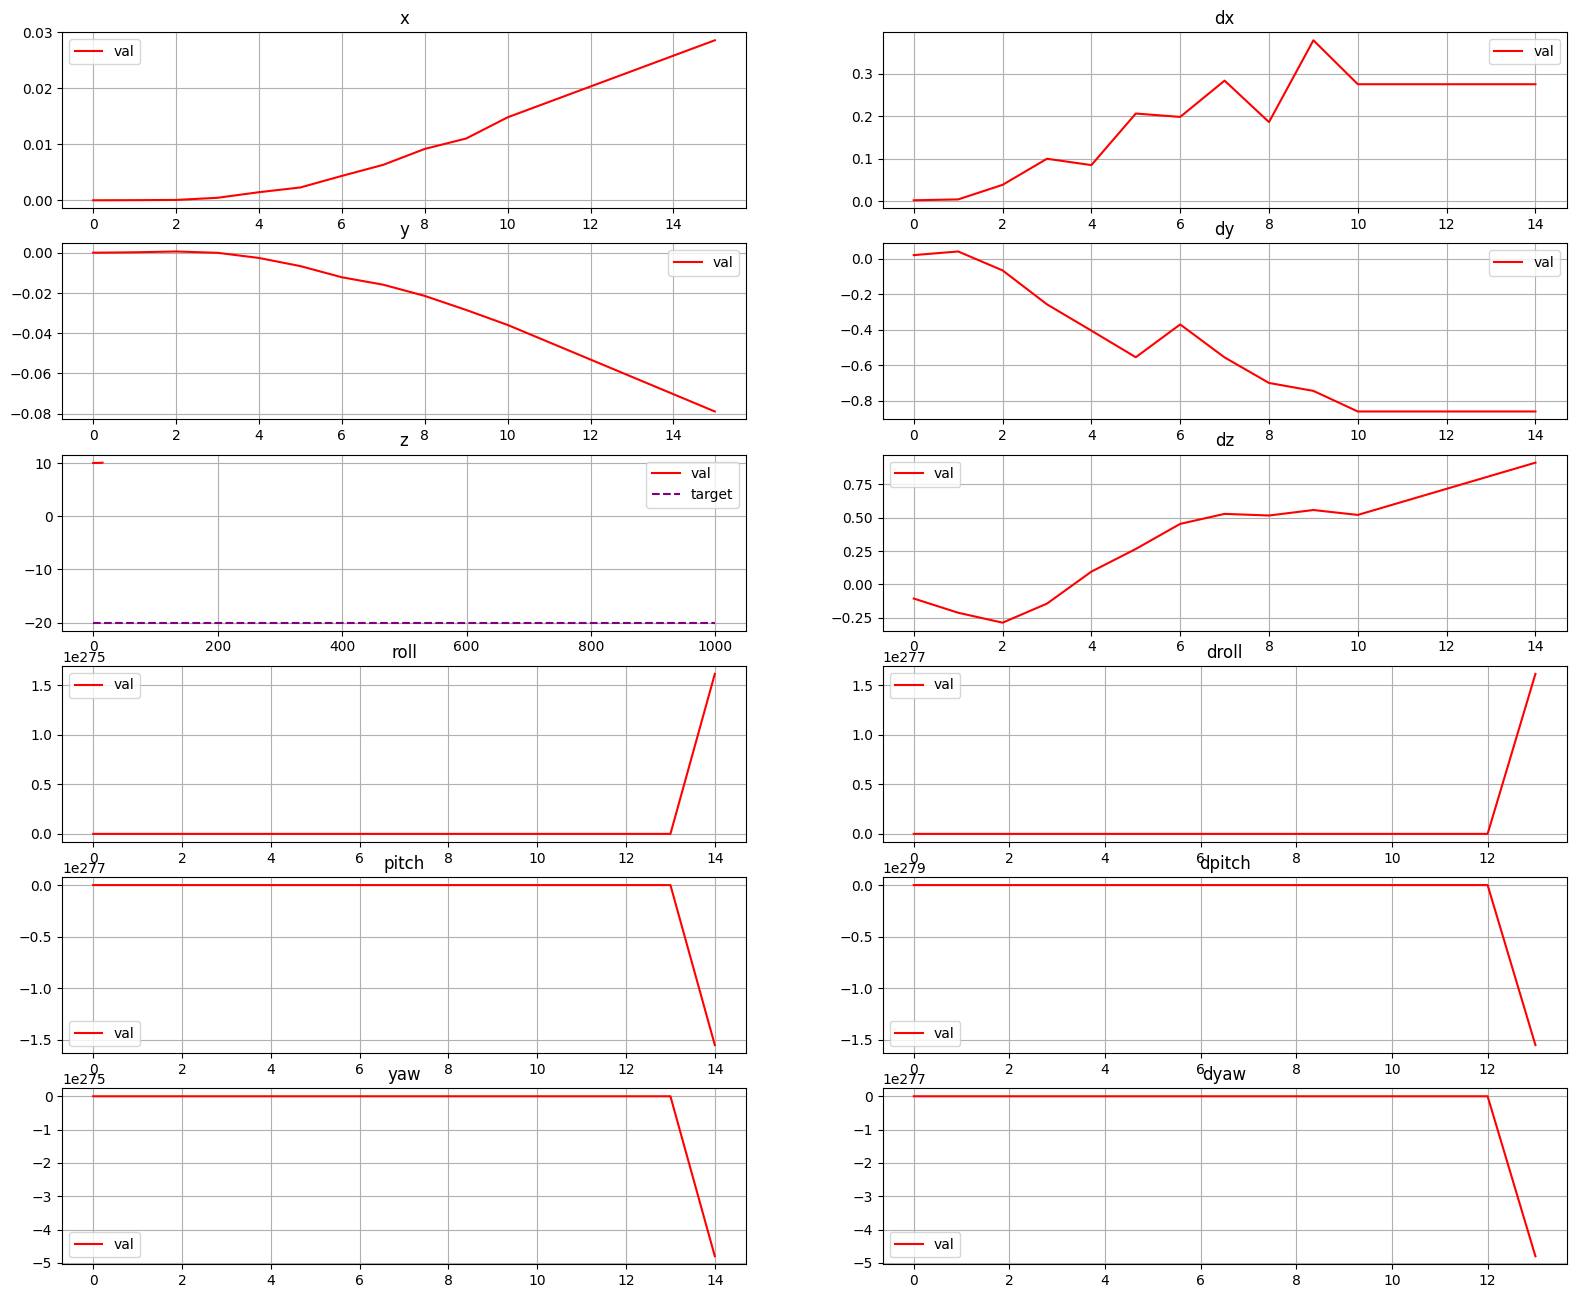

In [6]:
# Visualisation - State Variables
fig = plt.figure(figsize=(30, 16))
gs = GridSpec(6, 3, figure=fig)

for i,title in enumerate(['x','y','z','roll','pitch','yaw','dx','dy','dz','droll','dpitch','dyaw']):
    ax = fig.add_subplot(gs[i%6,i//6])
    t = range(0,x_bag[i,:].shape[0])
    ax.plot(t, x_bag[i,:], color='red', label='val')
    if title=='z':
        ax.plot(t, len(t)*[-20], color='purple', linestyle='--', label='target')
    ax.set_title(title)
    ax.grid()
    ax.legend()

plt.show()

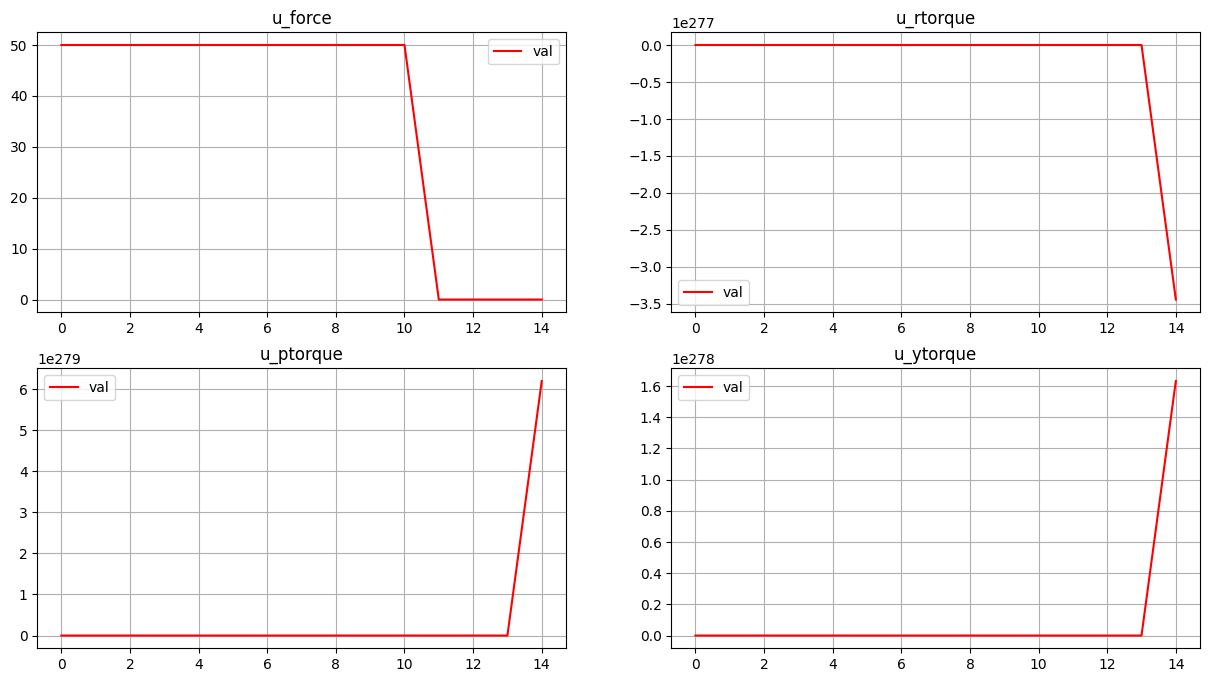

In [7]:
# Visualisation - State Variables
fig = plt.figure(figsize=(15, 8))
gs = GridSpec(2, 2, figure=fig)

for i,title in enumerate(['u_force', 'u_rtorque', 'u_ptorque', 'u_ytorque']):
    ax = fig.add_subplot(gs[i//2, i%2])
    t = range(0,len(ctx[title]))
    ax.plot(t, ctx[title], color='red', label='val')
    if title=='z':
        ax.plot(t, len(t)*[-20], color='purple', linestyle='--', label='target')
    ax.set_title(title)
    ax.grid()
    ax.legend()

plt.show()